In [1]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import re

# Prepare unified RI dataset:
- Calibrate the KPMS algorithm to learn the relationship between keypoint errors and confidence scores. This is done on the original data temporal resolution
- Downsampling videos to a common temporal resolution (10 FPS)
- Do keypoint interpolation on datasets that do not have frame rates multiples of 10 (e.g., 15 and 27 FPS)

There are different datasets with different FPS: 10, 15, 27, 30 and 50

### Setup project

In [29]:
dlc_config_file = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\config.yaml"

kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_KPMS_Resident"

kpms.setup_project(kpmoseq_dir, deeplabcut_config=dlc_config_file, overwrite = False)

config = lambda: kpms.load_config(kpmoseq_dir)

The directory `C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\t
rainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset
_topView_KPMS_Resident` already exists. Use `overwrite=True` or pick a
different name


### Use the last video of each mouse to calibrate KPMS (original frame rate)

Note that the trainingSessions dataset was initially analyzed using a multianimal model. For this reason the files were first converted to signle animal format using the Resident's keypoints.

The script used was: **__C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\convert_multiAnimal2singleAnimal_tracking_DLC.ipynb__**

In [38]:
datasets = [
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_trainingSessions_DLC_singleAnimal"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_maladapivePreScreening_DLC_singleAnimal"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_Stefanos_RIdataset_DLC_singleAnimal"),
]

all_h5 = [f for d in datasets for f in d.rglob("*.h5") if "_filtered" not in f.stem]

last = {}
for f in all_h5:
    mouse = f.stem.split("_Day")[0]
    day = int(re.search(r"_Day(\d+)", f.stem).group(1))
    if mouse not in last or day > last[mouse][0]:
        last[mouse] = (day, f)

calibration_files = [str(v[1]) for v in last.values()]

In [ ]:
from collections import defaultdict

mouse_datasets = defaultdict(set)
for f in all_h5:
    mouse_datasets[f.stem.split("_Day")[0]].add(next(d for d in datasets if f.is_relative_to(d)))

last = {}
for f in all_h5:
    mouse = f.stem.split("_Day")[0]
    if len(mouse_datasets[mouse]) > 1:      # skip mice found in more than one dataset
        continue
    day = int(re.search(r"_Day(\d+)", f.stem).group(1))
    if mouse not in last or day > last[mouse][0]:
        last[mouse] = (day, f)

calibration_files = [str(v[1]) for v in last.values()]

In [41]:
# For some reason, bodyparts returned from kpms.load_keypoints is of type "set", not "list". This means that bodypart label's order is not aligned anymore with the other variables 

with open(dlc_config_file, "r") as f:
        dlcConfig = yaml.safe_load(f)

bodyparts = dlcConfig["bodyparts"]

In [42]:
coordinates, confidences, bodyparts = kpms.load_keypoints(calibration_files, "deeplabcut")

Loading keypoints: 100%|██████████████| 141/141 [00:02<00:00, 69.88it/s]


In [ ]:
kpms.update_config(kpmoseq_dir, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [44]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

### Populate the video_dir (DLC) with the videos whose sessions are going to be used to calibration

In [51]:
import shutil

video_source_roots = [       # wherever the ORIGINAL videos actually live
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\trainingSessions"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\maladapivePreScreening"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\Stefanos_RIdataset"),
]

calib_video_dir = Path(kpmoseq_dir) / "calibration_videos"
calib_video_dir.mkdir(exist_ok=True)

exts = ("*.avi", "*.mp4")
index = {p.stem: p for root in video_source_roots for e in exts for p in root.rglob(e)}

missing = []
for key in coordinates:
    stem = key.split("DLC")[0]               # 'mouse1034811_Day005' or 'mouse..._topView_comp'
    if stem in index:
        shutil.copy2(index[stem], calib_video_dir / index[stem].name)
    else:
        missing.append(stem)

print("missing:", missing)

kpms.update_config(kpmoseq_dir, video_dir=str(calib_video_dir))

missing: []


In [53]:
import keypoint_moseq.calibration as _cal

# keep a stable reference to the real function (re-run safe)
if not hasattr(_cal, "_orig_sample_error_frames"):
    _cal._orig_sample_error_frames = _cal.sample_error_frames

def _sample_more(confidences, bodyparts, use_bodyparts,
                 num_bins=10, num_samples=200, conf_pseudocount=1e-3):
    return _cal._orig_sample_error_frames(
        confidences, bodyparts, use_bodyparts,
        num_bins=num_bins, num_samples=num_samples, conf_pseudocount=conf_pseudocount)

_cal.sample_error_frames = _sample_more

Loading sample frames: 100%|██████████| 200/200 [00:02<00:00, 73.79it/s]


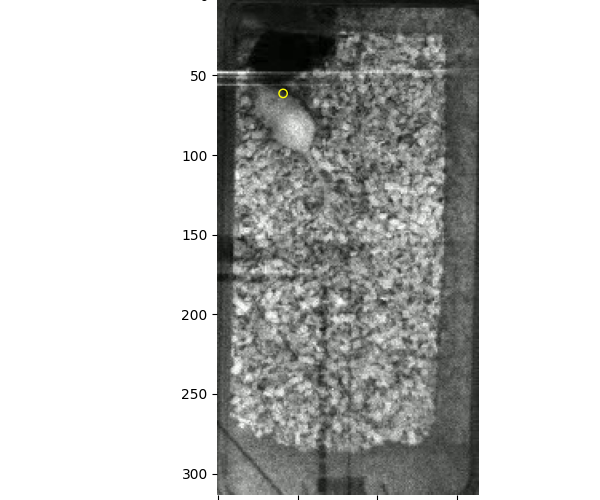

In [54]:
%matplotlib widget
kpms.noise_calibration(kpmoseq_dir, coordinates, confidences, overwrite = False, **config())